# Validation Log and Notebook for AlexNet


The following notebook is going to be used to tweak the alexnet model for the different datasets, this is going to be done in order to make sure that we are picking the right architecture and hyperparameters for the efficiency tradeoff comparison.


##  Parameters Hyperparameters that we are going to change and validate:

Parameters: this are specific to each convulotional layer and focus on modifying how the convulotion operation is applied across the image.
We have to be really careful with this parameter as they dictate how much they are moving.
* Stride: This parameter determines how many units the filter moves at each step.
* Padding: This parameter determines how many zeros are going to be added arounf the input matrix border ir order to retain edge information and avoid shrinking.


Hyperparameters: 

## Vanilla Architecture: AlexNet as it was written on the breakthrough paper.


For this first validation iteration I am going to use the classic alexnet iteration with the vanilla hyperparameter that where established in the AlexNet Paper breakthrough we will see the overall perfomance of this model with the architecture that we have and see if we have to change any of the specific hyperparameters or parameters in the layers.

The first convulotional layer is the one that transforms the input data so thats where we are going to tweak the parameters.
The other hyperparameters in the other layers are going to be fixed.


### Validation with the MNIST dataset.

In [3]:
%pip install torchvision

Because I am using Colab and I remote server I have to clone the repo to access the local models.

In [ ]:
import os

REPO_NAME = "4803_project_advanced_neural_networks"
REPO_URL = "https://github.com/zarcop/4803_project_advanced_neural_networks"

# Clone once; then pull updates on later runs.
if not os.path.isdir(REPO_NAME):
    !git clone {REPO_URL}
else:
    !git -C {REPO_NAME} pull



Cloning into '4803_project_advanced_neural_networks'...
remote: Enumerating objects: 70, done.
remote: Counting objects: 100% (70/70), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 70 (delta 27), reused 65 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (70/70), 22.32 MiB | 40.10 MiB/s, done.
Resolving deltas: 100% (27/27), done.
/bin/bash: line 1: cd: model: No such file or directory


In [20]:
# Use %cd so working directory persists across notebook cells.
%cd /content/4803_project_advanced_neural_networks
!ls



4803_project_advanced_neural_networks  sample_data


## Alternative Validation: Stratified K-Fold Cross-Validation (scikit-learn)

Using one fixed train/test split is fast, but it can make model selection sensitive to that specific split.  
For hyperparameter comparison, a stronger approach is to use **StratifiedKFold** over the training set and average performance across folds.

Notes for CNNs:
- We use sklearn only for fold generation (`StratifiedKFold`) and keep training in PyTorch.
- This is fully feasible for `k1`, `s1`, and `p1` combinations in `AlexNet4803`.
- It is more computationally expensive than a single split, so this example uses fewer epochs and an optional subset for speed.


100%|██████████| 9.91M/9.91M [00:00<00:00, 13.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 344kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.32MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 29.6MB/s]


CV Config: kernel: 3, stride : 1, padding: 1
Fold 1/3 | val_acc=97.25%
Fold 2/3 | val_acc=97.95%
Fold 3/3 | val_acc=97.22%
CV Config: kernel: 5, stride : 1, padding: 2
Fold 1/3 | val_acc=96.48%
Fold 2/3 | val_acc=96.00%
Fold 3/3 | val_acc=97.20%
CV Config: kernel: 5, stride : 2, padding: 2
Fold 1/3 | val_acc=97.48%
Fold 2/3 | val_acc=97.52%
Fold 3/3 | val_acc=95.23%
CV Config: kernel: 7, stride : 2, padding: 3
Fold 1/3 | val_acc=95.15%
Fold 2/3 | val_acc=96.75%
Fold 3/3 | val_acc=97.03%


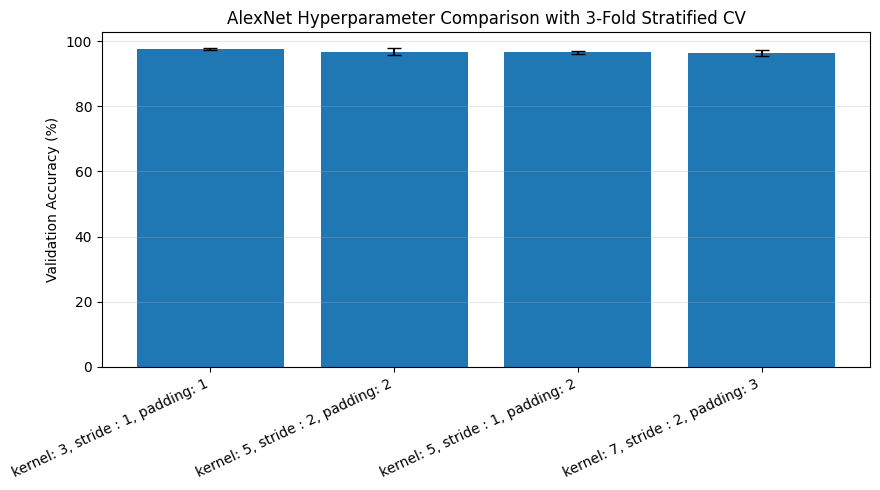


Best configuration by mean CV accuracy:
config         kernel: 3, stride : 1, padding: 1
mean_cv_acc                            97.471667
std_cv_acc                              0.341988
Name: 0, dtype: object


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import Subset
import torch
import importlib.util
import sys
from pathlib import Path
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from torch import nn, optim

# Robust import from repo path (works even if cwd changes).
repo_root = Path("/content/4803_project_advanced_neural_networks")
model_dir = repo_root / "model"
alexnet_path = model_dir / "alexnet.py"

if not alexnet_path.exists():
    raise FileNotFoundError(f"Could not find {alexnet_path}. Make sure clone/pull cell ran successfully.")

if str(model_dir) not in sys.path:
    sys.path.insert(0, str(model_dir))

spec = importlib.util.spec_from_file_location("alexnet", alexnet_path)
alexnet = importlib.util.module_from_spec(spec)
spec.loader.exec_module(alexnet)
AlexNet4803 = alexnet.AlexNet4803
#connecting to our cuda kernel (I am using my own colab server)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose(
    [
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
    ]
)
#downloading the data from MNIST
train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
batch_size = 128
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=0)

#seed for reprodusability
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

#evaluation function (going to be reused for all the validations)
def evaluate(model: nn.Module, loader: DataLoader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            pred = logits.argmax(dim=1)
            total += labels.size(0)
            correct += (pred == labels).sum().item()
    return 100.0 * correct / total

cv_dataset = train_data
cv_targets = np.array(train_data.targets)
#cross valiation hyperparameters
cv_hyperparameters = [
    {"k": 3, "s": 1, "p": 1, "name": "kernel: 3, stride : 1, padding: 1"},
    {"k": 5, "s": 1, "p": 2, "name": "kernel: 5, stride : 1, padding: 2"},
    {"k": 5, "s": 2, "p": 2, "name": "kernel: 5, stride : 2, padding: 2"},
    {"k": 7, "s": 2, "p": 3, "name": "kernel: 7, stride : 2, padding: 3"},
]
n_splits = 3
cv_epochs = 1
cv_batch_size = 128
lr = 1e-3

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
cv_records = []

#crossvalidation using skfold

for config in cv_hyperparameters:
    fold_accuracies = []
    print(f"CV Config: {config['name']}")

    for fold_id, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(cv_targets)), cv_targets), start=1):
        fold_train = Subset(cv_dataset, train_idx.tolist())
        fold_val = Subset(cv_dataset, val_idx.tolist())

        fold_train_loader = DataLoader(fold_train, batch_size=cv_batch_size, shuffle=True, num_workers=0)
        fold_val_loader = DataLoader(fold_val, batch_size=cv_batch_size, shuffle=False, num_workers=0)

        model = AlexNet4803(1, 10, k1=config["k"], s1=config["s"], p1=config["p"]).to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr)
        loss_fn = nn.CrossEntropyLoss()

        for _ in range(cv_epochs):
            model.train()
            for images, labels in fold_train_loader:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                loss = loss_fn(model(images), labels)
                loss.backward()
                optimizer.step()

        fold_acc = evaluate(model, fold_val_loader)
        fold_accuracies.append(fold_acc)
        print(f"Fold {fold_id}/{n_splits} | val_acc={fold_acc:.2f}%")

    mean_acc = float(np.mean(fold_accuracies))
    std_acc = float(np.std(fold_accuracies))
    cv_records.append(
        {
            "config": config["name"],
            "mean_cv_acc": mean_acc,
            "std_cv_acc": std_acc,
            "fold_accuracies": fold_accuracies,
        }
    )

cv_df = pd.DataFrame(cv_records).sort_values("mean_cv_acc", ascending=False).reset_index(drop=True)
cv_df

plt.figure(figsize=(9, 5))
plt.bar(
    cv_df["config"],
    cv_df["mean_cv_acc"],
    yerr=cv_df["std_cv_acc"],
    capsize=5,
)
plt.ylabel("Validation Accuracy (%)")
plt.title(f"AlexNet Hyperparameter Comparison with {n_splits}-Fold Stratified CV")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nBest configuration by mean CV accuracy:")
print(cv_df.iloc[0][["config", "mean_cv_acc", "std_cv_acc"]])
